# Face Mask Detection — EfficientNetB0 Transfer Learning

In Notebook 2, we used VGG16 for transfer learning. While it worked great (~98% accuracy) but VGG16 is a massive model (138 million parameters, ~528MB).

Here, we will use **EfficientNetB0**, a modern, state-of-the-art model that is much smaller (~4 million parameters) and highly optimized for speed and efficiency. We'll freeze the pre-trained EfficientNetB0 base and train a simple classification head on top.

## 1. Imports

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, GlobalAveragePooling2D
from keras.applications.efficientnet import EfficientNetB0, preprocess_input
from keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

## 2. Load the Dataset

Same dataset folder structure and loading process as notebooks 1 and 2. We resize all images to 224x224.

In [3]:
!git clone https://github.com/ricklon/pyimagesearch-face-mask-detector.git


Cloning into 'pyimagesearch-face-mask-detector'...
remote: Enumerating objects: 1311, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 1311 (delta 4), reused 0 (delta 0), pack-reused 1302 (from 1)
Receiving objects: 100% (1311/1311), 68.64 MiB | 12.00 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [4]:
# Clone the dataset (run once if not already cloned)
# !git clone https://github.com/ricklon/pyimagesearch-face-mask-detector.git

dataset_path = "/content/pyimagesearch-face-mask-detector/dataset"
categories = ['without_mask', 'with_mask']   # 0 = no mask, 1 = mask

print("Classes:", os.listdir(dataset_path))

Classes: ['with_mask', 'without_mask']


In [5]:
data = []
for category in categories:
    path = os.path.join(dataset_path, category)
    label = categories.index(category)

    for file in os.listdir(path):
        img_path = os.path.join(path, file)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (224, 224))
        data.append([img, label])

print(f"Total images loaded: {len(data)}")

Total images loaded: 1376


## 3. Preprocess & Split

For EfficientNetB0, the model itself has a built-in rescaling layer () as part of its network definition. This means  is actually a pass-through function that does nothing. However, we'll still call it to follow standard keras application workflows.

In [6]:
random.shuffle(data)

X = np.array([item[0] for item in data])
y = np.array([item[1] for item in data])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class distribution: no_mask={sum(y==0)}, mask={sum(y==1)}")

X shape: (1376, 224, 224, 3)
y shape: (1376,)
Class distribution: no_mask=686, mask=690


In [7]:
# Apply the pass-through preprocessing
X = preprocess_input(X)

# 70/15/15 split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Train: 963 | Val: 206 | Test: 207


## 4. Build the Model

Unlike VGG16 where we manually copied the dense layers, for EfficientNetB0 we will load the base model with  (dropping the final 1000-class classifier), freeze its weights, and add a  layer followed by a single  classification head.

This leaves us with only **1,281 trainable parameters** (vs 4,097 in VGG16) and a much smaller footprint!

In [8]:
# Load pre-trained EfficientNetB0 base
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model
base_model.trainable = False

# Build sequential model
model = Sequential()
model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 5. Train

We'll use similar callbacks and data augmentation as Notebook 2.

In [9]:
datagen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2
)

callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ModelCheckpoint('best_efficientnet_model.keras', save_best_only=True)
]

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)

Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.8951 - loss: 0.3641 - val_accuracy: 0.9903 - val_loss: 0.1375
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 350ms/step - accuracy: 0.9907 - loss: 0.1171 - val_accuracy: 0.9903 - val_loss: 0.0623
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 369ms/step - accuracy: 0.9938 - loss: 0.0695 - val_accuracy: 0.9951 - val_loss: 0.0415
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 374ms/step - accuracy: 0.9969 - loss: 0.0513 - val_accuracy: 0.9951 - val_loss: 0.0316
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 374ms/step - accuracy: 0.9969 - loss: 0.0423 - val_accuracy: 1.0000 - val_loss: 0.0255
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 390ms/step - accuracy: 0.9958 - loss: 0.0356 - val_accuracy: 1.0000 - val_loss: 0.0215
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 406ms/step - accuracy: 0.9990 - loss: 0.0267 - val_accuracy: 1.0000 - val_loss: 0.0186
Epoch 8/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 19s 370ms/step - accuracy: 0.9990 - loss: 0.0258 - val_accurac

## 6. Evaluate

In [10]:
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred,
      target_names=['without_mask', 'with_mask']))

7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step
              precision    recall  f1-score   support

without_mask       1.00      1.00      1.00        97
   with_mask       1.00      1.00      1.00       110

    accuracy                           1.00       207
   macro avg       1.00      1.00      1.00       207
weighted avg       1.00      1.00      1.00       207



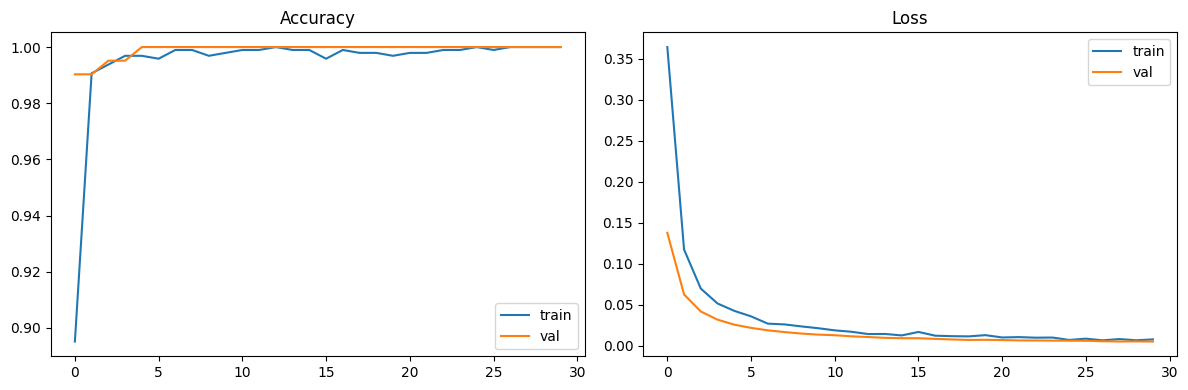

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='train')
ax1.plot(history.history['val_accuracy'], label='val')
ax1.set_title('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='train')
ax2.plot(history.history['val_loss'], label='val')
ax2.set_title('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

## 7. Takeaways

- EfficientNetB0 is a modern alternative that achieves similar accuracy to VGG16 but is **50x smaller** and much faster to run.
- Loading the base model with  lets us cleanly append a  layer and our  classifier, resulting in only **1,281 trainable parameters**.
- EfficientNet handles scaling and normalization internally, making it highly robust.
- **Verdict:** Transfer learning with EfficientNetB0 or MobileNetV2 is the optimal choice for real-time edge applications.

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,416 (15.46 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 2,564 (10.02 KB)